# Common Neighbour Analysis (CNA)

CNA is an analysis of the properties of pairs of atom. For each pair, a _signature_ in the shape $(r,s,t)$ is provided, where: 
 - $r$ is the number of nearest neighbours shared by the two atoms,
 - $s$ is the number of bonds between the shared neighbours,
 - $t$ is the longest chain which can be made from bonding $s$ atoms if they are neighbours.

We can further define, for each atom, the list of signatures corresponding to pairs that this atom is part of. This list defines the CNA pattern (CNAP) of the atom

CNA signatures and CNAPs can help us perform structure identification and recognition. Let's see how to compute and deal with these objects in atomistic systems with pySNOW.

In [18]:
from snow.io.xyz import read_xyz
from snow.descriptors import cna

In [25]:
#load data of a nanoparticle from an xyz file
el, coords = read_xyz('tutorial_structures/Cu247_Dh.xyz')

As with all properties based on the concept of nearest neighbours, we have to define a cutoff for to consider whether atoms are neighbouring or not. To do this, we have to look at the pair distance distribution function (PDDF) - see the corresponding tutorial. Here we suppose we already checked out the PDDF and obtained a reasonable value for the cutoff - we will choose $r_{cut}=0.89\cdot a_{lat}$, where $a_{lat}$ is the bulk lattice constant of the chemical specie we selected.

In [26]:
alat   = 3.61       #lattice constant of copper
cutoff = 0.89*alat

In [27]:
#compute the cna
n_pairs, signatures = cna.calculate_cna( coords, cutoff)

#print the first 3 signatures
print(signatures[:3])

#If needed, you can get the pairs list in the form of pairs of indexes 
#identifying the atoms that participate in the pair (use return_pair=True)
n_pairs, signatures, pairs_list = cna.calculate_cna(coords, cutoff, return_pair=True)

#print the index of the atoms in the pairs corresponding to the first three signatures
print(pairs_list[:3])

[[4. 2. 2.]
 [4. 2. 1.]
 [2. 1. 1.]]
[(52, 159), (24, 88), (166, 181)]


In [28]:
# a faster edition of the cna calculator function:
import time

start_fast = time.time()
n_pairs, signatures, pairs_list = cna.calculate_cna_fast(coords, cutoff, return_pair=True)
tic_fast = time.time() - start_fast

start_slow = time.time()
n_pairs, signatures, pairs_list = cna.calculate_cna(coords, cutoff, return_pair=True)
tic_slow = time.time() - start_slow

print(f'time for computing with the fast function: {tic_fast:.2e} sec')
print(f'time for computing with the slow function: {tic_slow:.2e} sec')


time for computing with the fast function: 8.71e-02 sec
time for computing with the slow function: 1.33e-01 sec


Now, suppose we want to move to per-atom properties, rather than per-pair properties. Let's compute, for each atom, all the signatures from pairs involving that atom.

In [29]:
cnas_atom = cna.cna_peratom(coords, cutoff)

#results are returned in the form (unique_signatures, number_of_occurrences) for each atom
atom_id = 15
print(cnas_atom[atom_id])

(array([[4., 2., 2.],
       [5., 5., 5.]]), array([10,  2]))


The atom with `atom_id=15` has 12 neighbours - in two of the resulting pairs the signature is $(5,5,5)$, and in the resulting ten the signature is $(4,2,2)$. We know that this signatures correspond to those of an atom lying on a five-fold symmetry axis, and we will show later how to use a function to automatically recognize known patterns. For now, let's suppose we want to see the distribution of patterns in our structure:

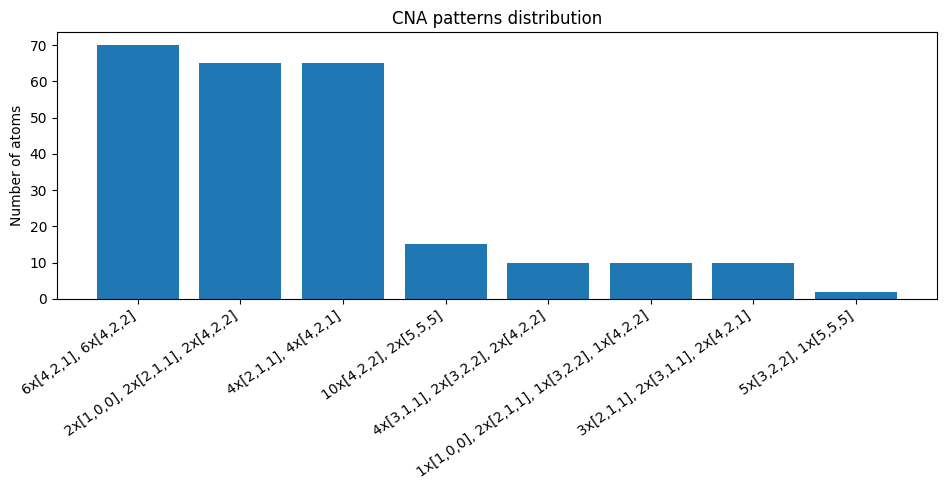

In [31]:
import matplotlib.pyplot as plt
import numpy as np 
from collections import Counter

def plot_cna_peratom(cna_atom, density=False):
    #an example funciton to plot the distribution of patterns
    #with care on permutation invariance of the order of the signatures written 
    #by the cna_peratom function
    pattern_counter = Counter()

    # Expand signatures by their counts, sort for permutation invariance
    for sigs, counts in cna_atom:
        expanded = []
        for sig, cnt in zip(sigs, counts):
            expanded.extend([tuple(sig)] * cnt) #explicitly write the list of N signatures
        pattern = tuple(sorted(expanded)) #sort
        pattern_counter[pattern] += 1

    # Build plot data sorted by frequency
    patterns, freq = zip(*pattern_counter.most_common())

    #a helper function to write nice labels
    def make_label(pattern):
        sig_counts = Counter(pattern)
        sorted_sigs = sorted(sig_counts.keys())
        return ", ".join(f"{sig_counts[(r,s,t)]}x[{int(r)},{int(s)},{int(t)}]" for r,s,t in sorted_sigs)

    labels = [make_label(p) for p in patterns]

    #normalize to get percentages, if wanted
    if density:
        freq = [f/np.sum(freq)*100. for f in freq]

    #plot
    fig, ax = plt.subplots(figsize=(max(6, len(patterns) * 1.2), 5))
    ax.bar(range(len(patterns)), freq)
    ax.set_xticks(range(len(patterns)))
    ax.set_xticklabels(labels, rotation=35., ha='right')
    if density:
        ax.set_ylabel('occurrence (%)')
    else:
        ax.set_ylabel("Number of atoms")
    ax.set_title("CNA patterns distribution")
    plt.tight_layout()
    plt.show()

plot_cna_peratom(cnas_atom, density=False)

There is a list of known CNAPs corresponding to specific environments, e.g., atoms in a bulk fcc lattice, icosahedron center, or (111) surface. A list of the CNAP-environment type is present in pySNOW's README, and is reported at the bottom of this page as well. A convenient pySNOW function can scan for matches in this list and return a number which is mapped to the environment type following the convention in the table below. This can be also used for visualization in softwares like OVITO.

In [33]:
cnaps = cna.cnap_peratom(coords, cutoff)

#example: print the first 5 cnap codes
print(cnaps[:5])

#it can be convenient to store information in an exported xyz file
from snow.io.xyz import write_xyz

write_xyz('tutorial_structures/Cu309_Ih_cnaps.xyz', el, coords, additional_data=cnaps)

[14  3  3  3  3]


By using the color coding function in ovito you can distinguish by color the environments of a system based on their (recognized) CNAPs.


<p>
  <img src="tutorial_structures/ico_309_in_cnaps.png" width="48%"/>
  <img src="tutorial_structures/ico_309_out_cnaps.png" width="48%"/>
</p>

With this colour coding, deep blue atoms have patterns that are not present in the list below. As you can see, there are still several environments to be classified. Please send us any new CNAPs that you identify!

The functions in cna also work for periodic structures - if this is your insterest, use `pbc=True` and pass the simulation `box` as arguments to the functions. 


| **CNAp** | **Description**                                      | **CNAp composition** |
|:--------:|------------------------------------------------------|:--------:|
| 1        | Vertex between two (111) facets and a (100) facet    |[(1, (100)), (2, (211)), (1, (322)), (1, (422))] |
| 2        | Edge between (100) and a slightly distorted (111)    |[(1, (200)), (2, (211)), (2, (311)), (1, (421))] |
| 3        | Atoms lying on a (555) symmetry axis                 |[(10, (422)), (2, (555))] |
| 4        | FCC bulk                                             |[(12, (421))] |
| 5        | Intersection of six five-fold axes                   |[(12, (555))] |
| 6        | Edge between (100) facets                            |[(2, (100)), (2, (211)), (2, (422))] |
| 7        | Vertex on twinning planes shared by (111) facets     |[(2, (200)), (1, (300)), (2, (311)), (1, (322)), (1, (422))] |
| 8        | Edge between (111) re-entrances and (111) facets     |[(2, (200)), (4, (311)), (1, (421))] |
| 9        | Re-entrance delimited by (111) facets                |[(2, (300)), (4, (311)), (2, (421)), (2, (422))] |
| 10       | Edge between (100) and (111) facets                  |[(3, (211)), (2, (311)), (2, (421))] |
| 11       | Vertex shared by (100) and (111) facets              |[(4, (211)), (1, (421))] |
| 12       | (100) facet                                          |[(4, (211)), (4, (421))] |
| 13       | Five-fold symmetry axis (without center)             |[(4, (311)), (2, (322)), (2, (422))] |
| 14       | Five-fold vertex                                     |[(5, (322)), (1, (555))] |
| 15       | (111) face                                           |[(6, (311)), (3, (421))] |
| 16       | Twinning plane                                       |[(6, (421)), (6, (422))] |
| 0        | All the others combinations    |[(..., (...)), ..., (..., (...))] |

In [34]:
cnaps

array([14,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3, 14,
       13, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 13, 13,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 13, 13, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 13, 13, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 13, 13, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 13,  1,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  1, 10, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 10,  1,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  1, 10, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 10,  1,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  1, 10, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 10,
        1,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  1, 10, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 10,  1,  6,  6,  6,
        6,  6,  6,  6,  6